# Statistic-build vs Prometheus-sink across sensor → edge_light → edge_heavy → cloud budgets

Reads per-condition × per-run time-series CSVs produced by `run_prometheus_benchmark.py`. The runner runs the nes-single-node-worker and (optionally) Prometheus inside **one Docker container with a shared CPU+memory budget**. The budget represents a deployment tier:

| Condition    | CPUs      | Memory    | Class |
|---|---|---|---|
| `cloud`      | unlimited | unlimited | server-class VM |
| `edge_heavy` | 8         | 8 GB      | workstation slice |
| `edge_light` | 4         | 4 GB      | NUC / gateway |
| `sensor`     | 1         | 1 GB      | Raspberry Pi / Jetson |

```
<benchmark_dir>/<condition>_<run>_throughput.csv
<benchmark_dir>/<condition>_<run>_latency.csv
<benchmark_dir>/summary.csv                        # one row per (condition, run); has oom_killed / exit_code
```

with `<condition> ∈ {cloud, edge_heavy, edge_light, sensor}` and `<run> ∈ {statistic_build, prometheus_sink}` — 8 throughput CSVs and 8 latency CSVs total.

Produce them in one invocation (the runner sweeps all four conditions by default):

```bash
OUTPUT_DIR=$PWD/runFull \
    bash scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/run_prometheus_benchmark.sh
```

Override any tier's budget via `EDGE_HEAVY_CPUS=… EDGE_HEAVY_MEMORY=…`, `EDGE_LIGHT_CPUS=… EDGE_LIGHT_MEMORY=…`, or `SENSOR_CPUS=… SENSOR_MEMORY=…`.

## Plot orientation

All plots facet by **condition** (cgroup budget) and overlay the two **runs** (`statistic_build` and `prometheus_sink`) within each panel — so each panel pins one budget and the comparison axis is "in-engine path vs co-located Prometheus path." This makes Plot 3's claim directly readable: as we move cloud → edge_heavy → edge_light → sensor, the Prometheus path falls behind faster than the in-engine path and may OOM at the lower tiers.

## Plots

**Plot 3 (paper-ready) — aggregate throughput over time with OOM annotation.** Four panels (`cloud` | `edge_heavy` | `edge_light` | `sensor`), two lines per panel (`statistic_build` solid+circle, `prometheus_sink` dashed+square). Vertical marker for "all queries submitted" per run. Red `OOM-killed` badge on any (condition, run) where `summary.csv` flags `oom_killed=True`. This is the figure intended for the paper.

Exploratory plots kept alongside for diagnosis:

1. **Per-query throughput over time** — one faint line per query, colored by run.
2. **Aggregate throughput over time** — sum across queries; two lines per panel.
3. **Latency CDF** — empirical CDF of per-task latency; two curves per panel.
4. **p99 latency over time** — p99 across queries of per-query mean-in-bin latency.

Then summary tables + plots:

5. **Overall median + p99** (split into one figure for throughput, one for latency).
6. **Per-query median + p99** distribution.

Vertical dashed line on every time-axis plot marks "all queries submitted" (`(N − 1) × launch_interval`). The final cell writes every figure as both PNG (300 dpi) and PDF into `<BENCHMARK_RUN>/figures/`, and summary CSVs into `<BENCHMARK_RUN>/summaries/`.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

In [2]:
### Set BENCHMARK_RUN to a specific directory, or leave None to auto-pick.
###
### Auto-pick order:
###   1. The notebook's own directory, if it contains <condition>_<run>_throughput.csv files
###      (handy when you scp the CSVs straight into plots/).
###   2. The most recent benchmark_run_* directory under the repository root.
BENCHMARK_RUN = None

### Bin width (ms) for aggregating samples on the time axis. The worker reports every
### ~200 ms so anything smaller is just noise; 1000 ms gives a clean second-by-second view.
BIN_MS = 1000

### Submission cadence + worker config — keep aligned with config.py. The plots use these to
### draw the "all queries submitted" marker and to annotate panels for paper-readiness.
### Default is the current config.py value (3s launch interval, 12 worker threads).
LAUNCH_INTERVAL_S = 3
WORKER_THREADS = 12

### Condition labels expected in the CSV filenames. Four deployment tiers, ordered from
### unconstrained to most constrained — `cloud` is the reference baseline; `edge_heavy`
### (8c/8g) is a workstation slice; `edge_light` (4c/4g) is a NUC/gateway; `sensor` (1c/1g)
### is a Pi/Jetson class budget. Each panel in the plots below pins one budget and overlays
### the two runs (engine path vs Prometheus path).
CONDITIONS = ["cloud", "edge_heavy", "edge_light", "sensor"]
RUN_NAMES = ["statistic_build", "prometheus_sink"]

### Display label for the cgroup budget shown under each condition on bar-chart x-ticks.
### `cloud` runs without --cpus/--memory caps; its label reflects the *host* capacity
### (amd7950x3d: 16 physical cores, 64 GB RAM) so the gradient is grounded in numbers.
### The other tiers match config.py's CONDITION_BUDGETS.
CONDITION_BUDGET_LABEL = {
    "cloud":      "16c / 64g",
    "edge_heavy": "8c / 8g",
    "edge_light": "4c / 4g",
    "sensor":     "1c / 1g",
}

### Friendly capitalized name for each condition; used in panel titles and tick labels.
CONDITION_DISPLAY_LABEL = {
    "cloud":      "Cloud",
    "edge_heavy": "Edge Heavy",
    "edge_light": "Edge Light",
    "sensor":     "Sensor",
}

### Display label for each run in plot legends and titles. CSV column / filename still uses
### the underlying RUN_NAMES; only what the reader sees changes.
RUN_DISPLAY_LABEL = {
    "statistic_build": "DELISEN",
    "prometheus_sink": "Prometheus",
}

### Pre-computed display-order lists used as col_order / hue_order across the plots below.
CONDITION_DISPLAY_ORDER = [CONDITION_DISPLAY_LABEL[c] for c in CONDITIONS]
RUN_DISPLAY_ORDER = [RUN_DISPLAY_LABEL[r] for r in RUN_NAMES]


def _has_csvs(directory):
    return any(
        os.path.exists(os.path.join(directory, f"{c}_{r}_throughput.csv"))
        for c in CONDITIONS
        for r in RUN_NAMES
    )


if BENCHMARK_RUN is None:
    notebook_dir = os.getcwd()
    if _has_csvs(notebook_dir):
        BENCHMARK_RUN = notebook_dir
    else:
        ### Notebook lives at scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/,
        ### so the repo root is four levels up.
        repo_root = os.path.abspath(os.path.join(notebook_dir, "..", "..", "..", ".."))
        candidates = sorted(glob.glob(os.path.join(repo_root, "benchmark_run_*")))
        assert candidates, (
            f"No <condition>_<run>_throughput.csv in {notebook_dir} and no benchmark_run_* "
            f"under {repo_root}.\nScp the CSVs into {notebook_dir} or set BENCHMARK_RUN "
            f"to an absolute path."
        )
        BENCHMARK_RUN = candidates[-1]

print("Using:", os.path.abspath(BENCHMARK_RUN))

Using: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots


In [3]:
def load(condition, run_name, metric):
    path = os.path.join(BENCHMARK_RUN, f"{condition}_{run_name}_{metric}.csv")
    if not os.path.exists(path):
        print(f"skipping missing file: {path}")
        return None
    df = pd.read_csv(path)
    df["run"] = run_name
    df["condition"] = condition
    return df


def _load_metric(metric):
    parts = [load(c, r, metric) for c in CONDITIONS for r in RUN_NAMES]
    parts = [p for p in parts if p is not None]
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


throughput = _load_metric("throughput")
latency = _load_metric("latency")


### summary.csv (one row per (condition, run)) carries the new oom_killed / exit_code columns.
### Older runs may not have these — fall back to all-False so plot annotations skip silently.
summary_path = os.path.join(BENCHMARK_RUN, "summary.csv")
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
else:
    summary_df = pd.DataFrame(columns=["condition", "run", "oom_killed", "exit_code"])
    print(f"note: no summary.csv at {summary_path}; OOM annotations disabled.")


def _oom_for(condition, run_name):
    """Return (oom_killed: bool, exit_code: int|None) for one (condition, run). Returns (False, None)
    when summary.csv is missing or doesn't have a row for this cell."""
    if summary_df.empty:
        return (False, None)
    row = summary_df[(summary_df["condition"] == condition) & (summary_df["run"] == run_name)]
    if row.empty:
        return (False, None)
    oom = bool(row.iloc[0].get("oom_killed", False))
    code = row.iloc[0].get("exit_code")
    if pd.isna(code):
        code = None
    else:
        try:
            code = int(code)
        except (TypeError, ValueError):
            code = None
    return (oom, code)


oom_flags = {(c, r): _oom_for(c, r) for c in CONDITIONS for r in RUN_NAMES}


### Per-(condition, run) summary stats — printed once and re-used as boxed annotations on plots.
### Computed from the data (not configured constants) so they reflect what was observed.
def _per_panel_stats(condition, run_name):
    tp = throughput[(throughput["condition"] == condition) & (throughput["run"] == run_name)] if not throughput.empty else throughput
    lat = latency[(latency["condition"] == condition) & (latency["run"] == run_name)] if not latency.empty else latency
    n_q = int(tp["query_id"].nunique() if not tp.empty else (lat["query_id"].nunique() if not lat.empty else 0))
    return {
        "n_queries": n_q,
        "throughput_samples": len(tp),
        "latency_samples": len(lat),
        "median_per_query_throughput": float(tp["throughput_tps"].median()) if len(tp) else float("nan"),
        "median_latency_us": float(lat["latency_s"].median() * 1e6) if len(lat) else float("nan"),
    }


panel_stats = {(c, r): _per_panel_stats(c, r) for c in CONDITIONS for r in RUN_NAMES}

for (c, r), s in panel_stats.items():
    oom, code = oom_flags.get((c, r), (False, None))
    oom_note = f"  [OOM-killed exit_code={code}]" if oom else ""
    print(f"=== {c} / {r} ==={oom_note}")
    print(f"  queries observed:           {s['n_queries']}")
    print(f"  throughput samples:         {s['throughput_samples']}")
    print(f"  latency samples:            {s['latency_samples']}")
    print(f"  median per-query tput:      {s['median_per_query_throughput']:.0f} tup/s")
    print(f"  median per-task latency:    {s['median_latency_us']:.1f} us")
    print(f"  launch interval:            {LAUNCH_INTERVAL_S} s")
    print(f"  worker threads (configured): {WORKER_THREADS}")

=== cloud / statistic_build ===
  queries observed:           20
  throughput samples:         9198
  latency samples:            25619851
  median per-query tput:      4017000 tup/s
  median per-task latency:    1.5 us
  launch interval:            3 s
  worker threads (configured): 12
=== cloud / prometheus_sink ===
  queries observed:           20
  throughput samples:         9264
  latency samples:            1867462
  median per-query tput:      380540 tup/s
  median per-task latency:    1.1 us
  launch interval:            3 s
  worker threads (configured): 12
=== edge_heavy / statistic_build ===
  queries observed:           20
  throughput samples:         9207
  latency samples:            13185222
  median per-query tput:      2084000 tup/s
  median per-task latency:    1.5 us
  launch interval:            3 s
  worker threads (configured): 12
=== edge_heavy / prometheus_sink ===
  queries observed:           20
  throughput samples:         9323
  latency samples:          

In [4]:
### Shared plot helpers + a dict to collect figures for the final save-to-disk cell.

FIGURES = {}


def _submission_end_time(condition, run_name):
    """Wall-clock seconds at which the last query for (condition, run) was submitted,
    i.e. (N - 1) * launch_interval, where N comes from the observed query count.
    Returns None when the panel is empty."""
    n = panel_stats.get((condition, run_name), {}).get("n_queries", 0)
    if n <= 0:
        return None
    return (n - 1) * LAUNCH_INTERVAL_S


def annotate_submission_marker(ax, condition, run_name):
    """Vertical dashed line at the moment the last query for one (condition, run) was submitted.

    No text label — the line position alone is enough now that the plots are quieter.
    Plots faceted by condition with hue=run still call this once per run within each panel,
    so a slowest-run-OOM'd vs healthy-run gap is visible if both runs survived to different t.
    """
    t = _submission_end_time(condition, run_name)
    if t is None:
        return
    ax.axvline(t, color="black", linestyle="--", linewidth=0.7, alpha=0.4)


def map_display_columns(df):
    """Return *df* with two extra columns (run_display, condition_display) holding the
    paper-friendly names from RUN_DISPLAY_LABEL / CONDITION_DISPLAY_LABEL. The original
    'run' and 'condition' columns are left untouched so the panel_stats / oom_flags
    lookups keep working with the raw keys."""
    out = df.copy()
    if "run" in out.columns:
        out["run_display"] = out["run"].map(RUN_DISPLAY_LABEL).fillna(out["run"])
    if "condition" in out.columns:
        out["condition_display"] = out["condition"].map(CONDITION_DISPLAY_LABEL).fillna(out["condition"])
    return out

## Per-query throughput over time

One faint line per query, **colored by run** (`statistic_build` vs `prometheus_sink`). Each panel pins one cgroup budget. The contention story: within the `limited` panel the `prometheus_sink` lines should fall below `statistic_build`.

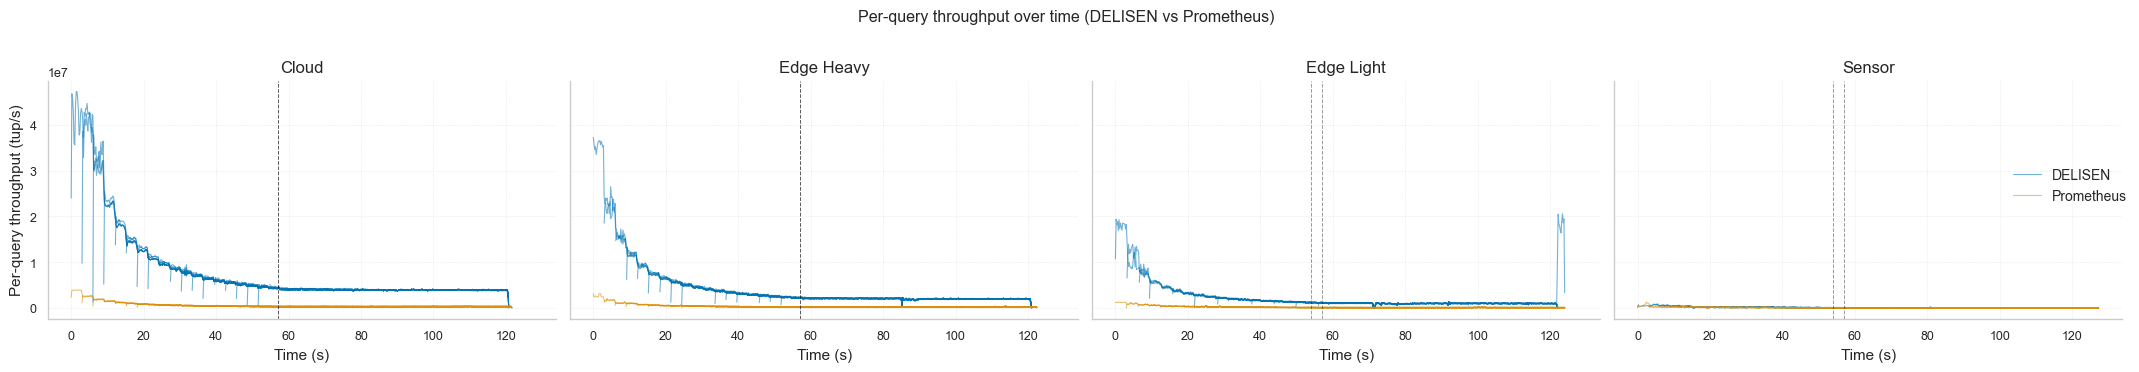

In [5]:
tp = map_display_columns(throughput.copy())
tp["time_s"] = tp["window_start_ms_normalized"] / 1000.0

with sns.plotting_context("paper", rc={
    "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
}):
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    g = sns.relplot(
        data=tp,
        x="time_s",
        y="throughput_tps",
        col="condition_display",
        col_order=CONDITION_DISPLAY_ORDER,
        hue="run_display",
        hue_order=RUN_DISPLAY_ORDER,
        palette=palette,
        units="query_id",
        estimator=None,
        kind="line",
        facet_kws={"sharey": True, "sharex": True},
        height=3.6,
        aspect=1.4,
        alpha=0.55,
        linewidth=0.8,
    )
    ### Iterate raw conditions so panel_stats / oom_flags lookups still use the keys we stored.
    for raw_c, display_c in zip(CONDITIONS, CONDITION_DISPLAY_ORDER):
        ax = g.axes_dict.get(display_c)
        if ax is None:
            continue
        for r in RUN_NAMES:
            annotate_submission_marker(ax, raw_c, r)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Per-query throughput (tup/s)")
        ax.set_title(display_c)
        ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)
    ### Drop the legend title ("run_display") — the two labels alone are clear.
    if g._legend is not None:
        g._legend.set_title(None)
    g.fig.suptitle("Per-query throughput over time (DELISEN vs Prometheus)", y=1.02)
    plt.tight_layout()
    FIGURES["per_query_throughput"] = g.fig
    plt.show()

## Aggregate throughput over time

Sum of per-query throughput per bin. **Panels = cgroup budget, lines = run.** Read the `limited` panel for the contention story; `unlimited` is the reference baseline.

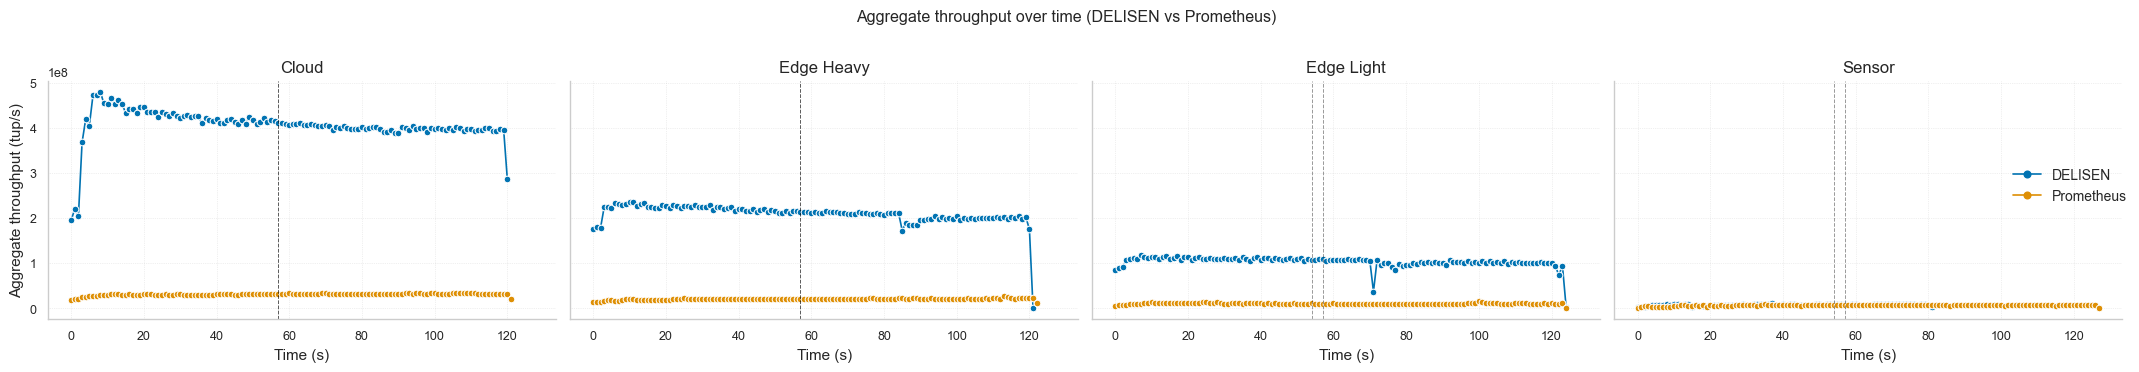

In [6]:
tp = throughput.copy()
tp["time_bin_s"] = (tp["window_start_ms_normalized"] // BIN_MS) * BIN_MS / 1000.0
tp_agg = tp.groupby(["condition", "run", "time_bin_s"], as_index=False)["throughput_tps"].sum()
tp_agg = map_display_columns(tp_agg)

with sns.plotting_context("paper", rc={
    "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
}):
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    g = sns.relplot(
        data=tp_agg,
        x="time_bin_s",
        y="throughput_tps",
        col="condition_display",
        col_order=CONDITION_DISPLAY_ORDER,
        hue="run_display",
        hue_order=RUN_DISPLAY_ORDER,
        palette=palette,
        kind="line",
        marker="o",
        facet_kws={"sharey": True},
        height=3.6,
        aspect=1.4,
    )
    for raw_c, display_c in zip(CONDITIONS, CONDITION_DISPLAY_ORDER):
        ax = g.axes_dict.get(display_c)
        if ax is None:
            continue
        for r in RUN_NAMES:
            annotate_submission_marker(ax, raw_c, r)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Aggregate throughput (tup/s)")
        ax.set_title(display_c)
        ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)
    if g._legend is not None:
        g._legend.set_title(None)
    g.fig.suptitle("Aggregate throughput over time (DELISEN vs Prometheus)", y=1.02)
    plt.tight_layout()
    FIGURES["aggregate_throughput"] = g.fig
    plt.show()

## Plot 3 (paper-ready): in-engine statistics vs side-by-side Prometheus

**The figure** for the paper claim: under a shared CPU+memory cgroup budget, swapping the in-engine statistic build for a co-located Prometheus sink steals resources from query execution. Each panel pins one budget (`unlimited` baseline, `limited` constrained); each line is one run. In the `limited` panel the `prometheus_sink` line should sit far below the `statistic_build` line — and may go OOM, in which case the red badge fires.

Style: `statistic_build` solid + circle, `prometheus_sink` dashed + square. Vertical dotted lines mark "all queries submitted" per run. Saves to `figures/plot3_aggregate_throughput.{png,pdf}`.

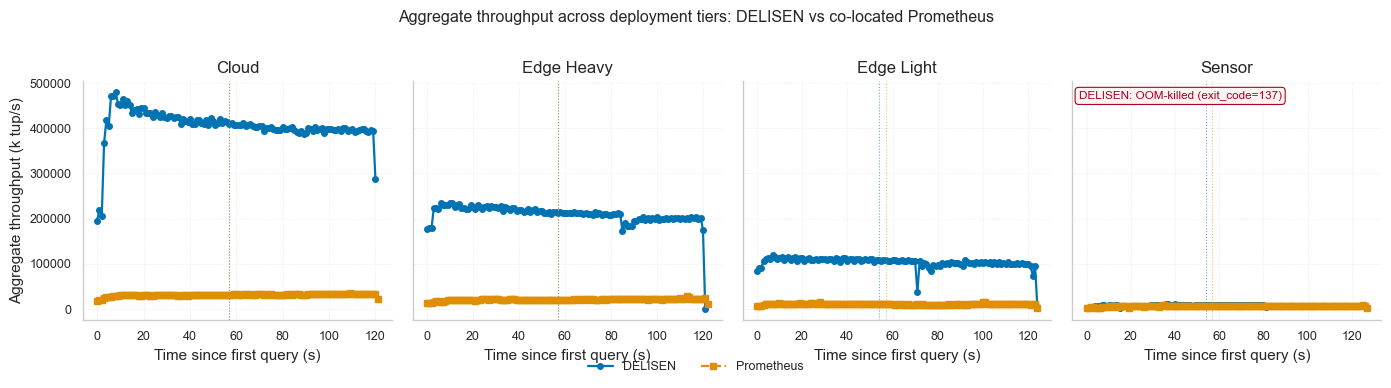

In [7]:
### Plot 3 — paper-ready aggregate throughput.
###
### Panels = cgroup budget (one per CONDITION); lines = run (DELISEN vs Prometheus).
### y-axis is the per-second SUM of per-query throughput, so we plot what the SYSTEM produces
### (not one query). Reading the figure: as we move from cloud → edge → sensor the budget
### tightens; the Prometheus line should fall faster than DELISEN, and may OOM (red badge) at
### the sensor tier.

tp_paper = throughput.copy()
tp_paper["time_bin_s"] = (tp_paper["window_start_ms_normalized"] // BIN_MS) * BIN_MS / 1000.0
tp_paper_agg = (
    tp_paper.groupby(["condition", "run", "time_bin_s"], as_index=False)["throughput_tps"].sum()
)
### Convert tup/s -> ktup/s for axis readability; reviewers prefer 1.2 over 1,200,000.
tp_paper_agg["throughput_ktps"] = tp_paper_agg["throughput_tps"] / 1_000.0

### Paper-friendly style overrides applied locally so we don't disturb the rest of the notebook.
with sns.plotting_context("paper", rc={"axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 9,
                                       "xtick.labelsize": 9, "ytick.labelsize": 9}):
    ### Solid/circle = in-engine path (DELISEN), dashed/square = SOTA Prometheus path.
    ### Keeps the engine-vs-Prometheus distinction visible even in grayscale prints.
    style_map = {"statistic_build": ("-", "o"), "prometheus_sink": ("--", "s")}
    ### figsize widens with each extra condition (3.5 in per panel) so adding a tier doesn't squish
    ### the existing panels.
    fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(3.5 * len(CONDITIONS), 3.6), sharey=True)
    if len(CONDITIONS) == 1:
        axes = [axes]
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    color_for = dict(zip(RUN_NAMES, palette))

    for ax, condition in zip(axes, CONDITIONS):
        panel = tp_paper_agg[tp_paper_agg["condition"] == condition]
        for run_name in RUN_NAMES:
            sub = panel[panel["run"] == run_name].sort_values("time_bin_s")
            if sub.empty:
                continue
            ls, marker = style_map.get(run_name, ("-", "o"))
            ax.plot(
                sub["time_bin_s"],
                sub["throughput_ktps"],
                linestyle=ls,
                marker=marker,
                markersize=4,
                linewidth=1.6,
                color=color_for[run_name],
                label=RUN_DISPLAY_LABEL[run_name],
            )
            ### "All queries submitted" reference per run.
            n = panel_stats.get((condition, run_name), {}).get("n_queries", 0)
            if n > 0:
                t_submit = (n - 1) * LAUNCH_INTERVAL_S
                ax.axvline(t_submit, color=color_for[run_name], linestyle=":", linewidth=0.8, alpha=0.6)

        ### OOM badge: list every (run) in this condition's panel that hit OOM.
        badges = []
        for run_name in RUN_NAMES:
            oom, code = oom_flags.get((condition, run_name), (False, None))
            if oom:
                badges.append(f"{RUN_DISPLAY_LABEL[run_name]}: OOM-killed (exit_code={code})")
        if badges:
            ax.text(
                0.02, 0.96,
                "\n".join(badges),
                transform=ax.transAxes,
                fontsize=8.5,
                verticalalignment="top",
                color="#b00020",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff4f4", edgecolor="#b00020", linewidth=0.8),
            )

        ax.set_title(CONDITION_DISPLAY_LABEL[condition])
        ax.set_xlabel("Time since first query (s)")
        ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Aggregate throughput (k tup/s)")

    ### Single legend below the panel grid — paper figures usually want this outside the data area.
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels,
            loc="lower center",
            ncol=len(RUN_NAMES),
            bbox_to_anchor=(0.5, -0.02),
            frameon=False,
        )
    fig.suptitle("Aggregate throughput across deployment tiers: DELISEN vs co-located Prometheus", y=1.02)
    fig.tight_layout()

    FIGURES["plot3_aggregate_throughput"] = fig
    plt.show()

## Latency CDF

Empirical CDF over per-task latency. Panels = cgroup budget, curves = run. The tail (right side) is where the Prometheus path drags out under contention.

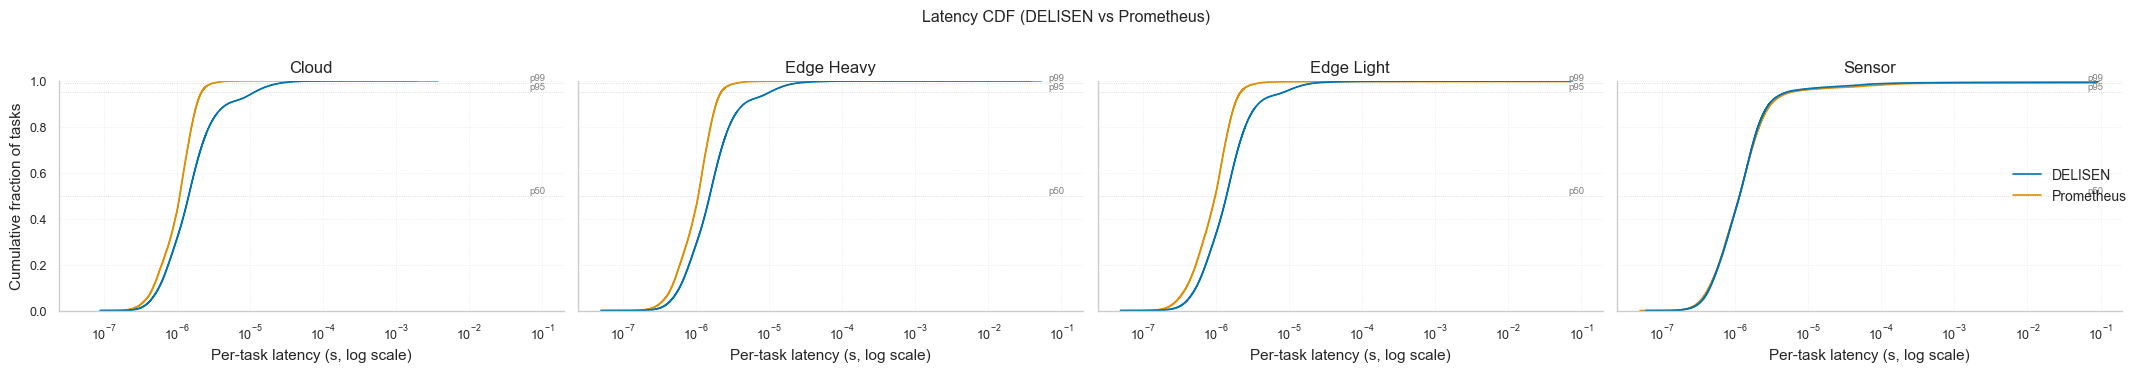

In [8]:
lat_display = map_display_columns(latency)

with sns.plotting_context("paper", rc={
    "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
}):
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    g = sns.displot(
        data=lat_display,
        x="latency_s",
        col="condition_display",
        col_order=CONDITION_DISPLAY_ORDER,
        hue="run_display",
        hue_order=RUN_DISPLAY_ORDER,
        palette=palette,
        kind="ecdf",
        log_scale=(True, False),
        height=3.6,
        aspect=1.4,
        facet_kws={"sharex": True, "sharey": True},
    )
    for display_c, ax in g.axes_dict.items():
        ### p50 / p95 / p99 reference lines for quick tail reads.
        for q, label in [(0.5, "p50"), (0.95, "p95"), (0.99, "p99")]:
            ax.axhline(q, color="lightgray", linestyle=":", linewidth=0.6, zorder=0)
            ax.annotate(
                label,
                xy=(ax.get_xlim()[1], q),
                xycoords="data",
                xytext=(-25, 2),
                textcoords="offset points",
                fontsize=7,
                color="gray",
            )
        ax.set_xlabel("Per-task latency (s, log scale)")
        ax.set_ylabel("Cumulative fraction of tasks")
        ax.set_title(display_c)
        ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.5)
        sns.despine(ax=ax)
    if g._legend is not None:
        g._legend.set_title(None)
    g.fig.suptitle("Latency CDF (DELISEN vs Prometheus)", y=1.02)
    plt.tight_layout()
    FIGURES["latency_cdf"] = g.fig
    plt.show()

## p99 latency over time

Per (condition, run, time_bin): reduce each query to its **mean** in-bin latency, then take the **p99** across queries. Panels = cgroup budget, lines = run. Time-resolved view of the tail.

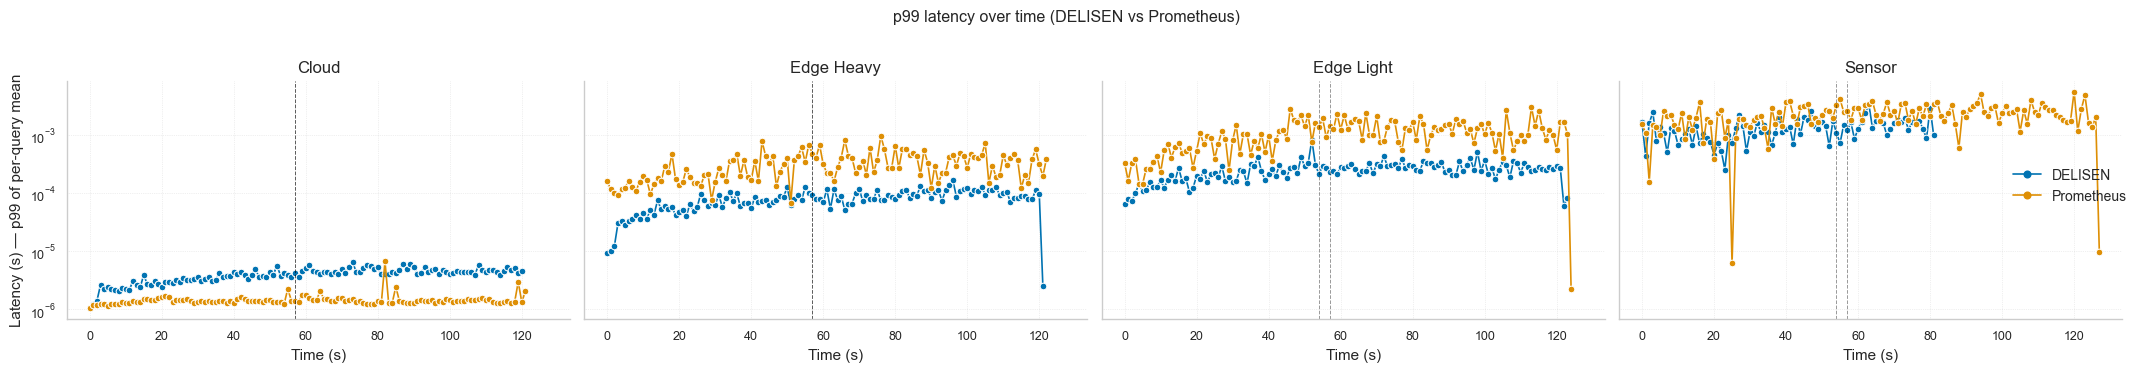

In [9]:
lat = latency.copy()
lat["time_bin_s"] = (lat["duration_start_ms_normalized"] // BIN_MS) * BIN_MS / 1000.0

per_query_mean = (
    lat.groupby(["condition", "run", "time_bin_s", "query_id"], as_index=False)["latency_s"].mean()
)
lat_p99 = (
    per_query_mean.groupby(["condition", "run", "time_bin_s"])["latency_s"]
    .quantile(0.99)
    .reset_index()
)
lat_p99 = map_display_columns(lat_p99)

with sns.plotting_context("paper", rc={
    "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
}):
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    g = sns.relplot(
        data=lat_p99,
        x="time_bin_s",
        y="latency_s",
        col="condition_display",
        col_order=CONDITION_DISPLAY_ORDER,
        hue="run_display",
        hue_order=RUN_DISPLAY_ORDER,
        palette=palette,
        kind="line",
        marker="o",
        facet_kws={"sharey": True},
        height=3.6,
        aspect=1.4,
    )
    for raw_c, display_c in zip(CONDITIONS, CONDITION_DISPLAY_ORDER):
        ax = g.axes_dict.get(display_c)
        if ax is None:
            continue
        for r in RUN_NAMES:
            annotate_submission_marker(ax, raw_c, r)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Latency (s) — p99 of per-query mean")
        ax.set_yscale("log")
        ax.set_title(display_c)
        ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)
    if g._legend is not None:
        g._legend.set_title(None)
    g.fig.suptitle("p99 latency over time (DELISEN vs Prometheus)", y=1.02)
    plt.tight_layout()
    FIGURES["latency_p99_over_time"] = g.fig
    plt.show()

## Median + p99 summaries

For each (condition, run): median and p99 of throughput (`tup/s`) and per-task latency (`us`). Computed two ways:

- **Per-query**: aggregate across each query's own samples, then keep one row per (condition, run, query_id) — preview shown inline, full tables written to `<BENCHMARK_RUN>/summaries/`.
- **Overall**: aggregate across every sample regardless of which query produced it — one row per (condition, run). Also drawn as a 2×2 bar grid so the throttle's effect on each metric is visible at a glance.

In [10]:
def _summarize(df, value_col, group_cols):
    """Group by *group_cols* and emit one row per group with median + p99 of *value_col*."""
    if df.empty:
        return pd.DataFrame(columns=group_cols + ["median", "p99"])
    g = df.groupby(group_cols)[value_col]
    return pd.concat([g.median().rename("median"), g.quantile(0.99).rename("p99")], axis=1).reset_index()


### Per-query: one row per (condition, run, query_id).
tp_per_query = _summarize(throughput, "throughput_tps", ["condition", "run", "query_id"])
lat_per_query = _summarize(latency, "latency_s", ["condition", "run", "query_id"])

### Overall: one row per (condition, run); aggregates every per-window sample.
tp_overall = _summarize(throughput, "throughput_tps", ["condition", "run"])
lat_overall = _summarize(latency, "latency_s", ["condition", "run"])

### Combined paper-style table: throughput in tup/s, latency converted to us.
overall = tp_overall.rename(columns={"median": "throughput_median_tps", "p99": "throughput_p99_tps"}).merge(
    lat_overall.rename(columns={"median": "latency_median_s", "p99": "latency_p99_s"}),
    on=["condition", "run"], how="outer",
)
overall["latency_median_us"] = overall["latency_median_s"] * 1e6
overall["latency_p99_us"] = overall["latency_p99_s"] * 1e6
overall_display = overall[
    ["condition", "run", "throughput_median_tps", "throughput_p99_tps", "latency_median_us", "latency_p99_us"]
]

print("=== Overall (across queries, across windows) ===")
print(overall_display.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

### Per-query previews — full tables go to CSV below.
lat_per_query_us = lat_per_query.assign(
    median_us=lat_per_query["median"] * 1e6, p99_us=lat_per_query["p99"] * 1e6,
)[["condition", "run", "query_id", "median_us", "p99_us"]]

print("\n=== Per-query throughput (first 20 rows; full table written to CSV) ===")
print(tp_per_query.head(20).to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print("\n=== Per-query latency (first 20 rows, microseconds; full table written to CSV) ===")
print(lat_per_query_us.head(20).to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

### Persist the full tables so they can be cited from the paper without rerunning the notebook.
SUMMARY_DIR = os.path.join(BENCHMARK_RUN, "summaries")
os.makedirs(SUMMARY_DIR, exist_ok=True)
tp_per_query.to_csv(os.path.join(SUMMARY_DIR, "per_query_throughput_summary.csv"), index=False)
lat_per_query.to_csv(os.path.join(SUMMARY_DIR, "per_query_latency_summary.csv"), index=False)
overall.to_csv(os.path.join(SUMMARY_DIR, "overall_summary.csv"), index=False)
print(f"\nsummaries written under: {os.path.abspath(SUMMARY_DIR)}")

=== Overall (across queries, across windows) ===
 condition             run  throughput_median_tps  throughput_p99_tps  latency_median_us  latency_p99_us
     cloud prometheus_sink             380,540.00        1,608,000.00               1.10            3.26
     cloud statistic_build           4,017,000.00       24,414,420.00               1.46           27.11
edge_heavy prometheus_sink             255,030.00        1,063,560.00               1.07            3.67
edge_heavy statistic_build           2,084,000.00       13,214,640.00               1.54           24.90
edge_light prometheus_sink             134,020.00          676,462.10               0.99            4.02
edge_light statistic_build           1,052,000.00        7,037,570.00               1.41           23.27
    sensor prometheus_sink              77,485.00          270,170.00               1.15        5,204.32
    sensor statistic_build             106,795.00          555,015.70               1.15          206.34

=== P

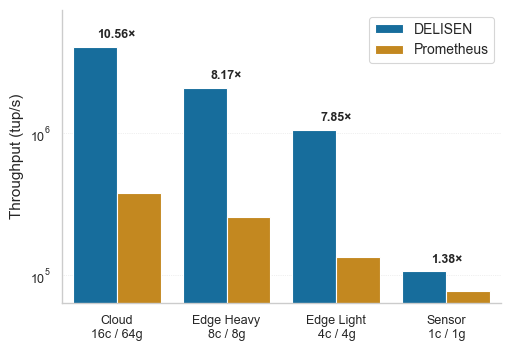

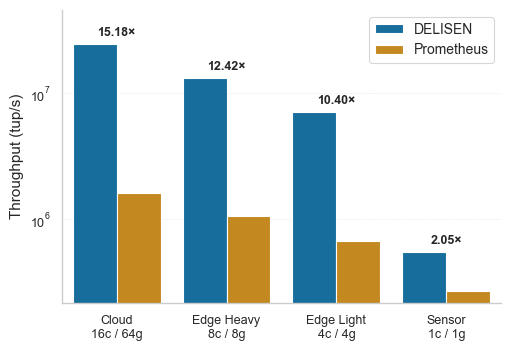

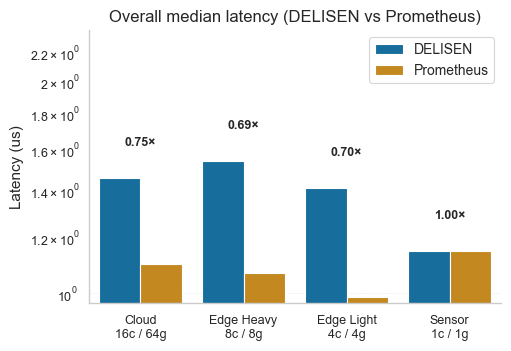

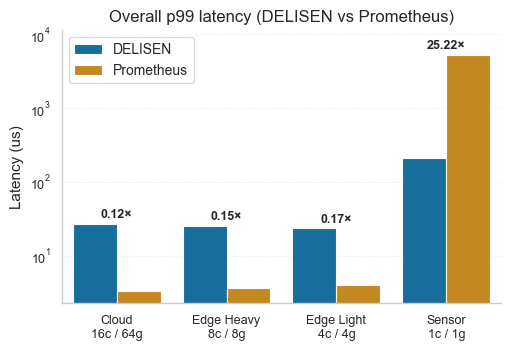

In [11]:
### Overall median + p99 — one figure per (metric, aggregation), so each one saves as its
### own PDF (4 PDFs total: median/p99 × throughput/latency). The save cell at the bottom
### just iterates FIGURES, so adding entries here is enough.
###
### Above each bar group we annotate the speedup of DELISEN over Prometheus — i.e., "by how
### many times does the in-engine path beat SOTA here?". For throughput (higher is better)
### speedup = DELISEN / Prometheus. For latency (lower is better) it flips to
### Prometheus / DELISEN, so >1 always means DELISEN wins and <1 means Prometheus wins.

bar_long = pd.concat(
    [
        overall.assign(metric="throughput_tps", aggregation="median", value=overall["throughput_median_tps"]),
        overall.assign(metric="throughput_tps", aggregation="p99",    value=overall["throughput_p99_tps"]),
        overall.assign(metric="latency_us",     aggregation="median", value=overall["latency_median_us"]),
        overall.assign(metric="latency_us",     aggregation="p99",    value=overall["latency_p99_us"]),
    ],
    ignore_index=True,
)[["condition", "run", "metric", "aggregation", "value"]]


def _draw_overall_one(metric, aggregation, ylabel, fig_key, suptitle, *, value_scale=1.0, lower_is_better=False):
    """Render ONE bar chart (one metric × one aggregation) into its own figure. Each condition's
    pair of bars gets a single centered speedup annotation (DELISEN relative to Prometheus)
    instead of per-bar value labels. value_scale is available for re-unit-ing the y-axis (e.g.
    tup/s -> M tup/s) when that's wanted."""
    panel = bar_long[(bar_long["metric"] == metric) & (bar_long["aggregation"] == aggregation)].copy()
    panel["value"] = panel["value"] * value_scale
    ### Render via the display label so the legend reads DELISEN / Prometheus, not statistic_build / prometheus_sink.
    panel["run_display"] = panel["run"].map(RUN_DISPLAY_LABEL)
    display_hue_order = [RUN_DISPLAY_LABEL[r] for r in RUN_NAMES]

    with sns.plotting_context("paper", rc={
        "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
        "xtick.labelsize": 9, "ytick.labelsize": 9,
    }):
        palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
        fig, ax = plt.subplots(figsize=(5.2, 3.6))
        sns.barplot(
            data=panel,
            x="condition", order=CONDITIONS,
            y="value",
            hue="run_display", hue_order=display_hue_order,
            palette=palette,
            errorbar=None,
            ax=ax,
        )
        ### No x-axis label — the two-line tick labels (condition + cgroup budget) already explain the x-axis.
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.set_title(suptitle)
        ### Log y-axis so the sensor-tier outliers (esp. p99 latency = 5 ms) don't squash everything else.
        ax.set_yscale("log")
        ### Two-line x-tick labels: friendly condition name on top, cgroup budget underneath.
        ax.set_xticks(range(len(CONDITIONS)))
        ax.set_xticklabels([
            f"{CONDITION_DISPLAY_LABEL.get(c, c)}\n{CONDITION_BUDGET_LABEL.get(c, '')}"
            for c in CONDITIONS
        ])
        ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)

        ### Pivot to (condition, run) so we can compute the per-condition ratio cleanly.
        pivot = panel.pivot(index="condition", columns="run", values="value").reindex(CONDITIONS)
        for i, condition in enumerate(CONDITIONS):
            if condition not in pivot.index:
                continue
            sb = pivot.at[condition, "statistic_build"] if "statistic_build" in pivot.columns else float("nan")
            ps = pivot.at[condition, "prometheus_sink"] if "prometheus_sink" in pivot.columns else float("nan")
            if pd.isna(sb) or pd.isna(ps) or sb == 0 or ps == 0:
                continue
            ### Direction-aware speedup: throughput uses DELISEN/Prom (higher=better), latency uses
            ### Prom/DELISEN (lower=better). Either way, >1 means DELISEN is the winner.
            speedup = (ps / sb) if lower_is_better else (sb / ps)
            top = max(sb, ps)
            ax.text(
                i, top * 1.10, f"{speedup:.2f}×",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold",
            )

        ### Headroom above the tallest bar so the speedup label isn't clipped against the axes box.
        y0, y1 = ax.get_ylim()
        ax.set_ylim(y0, y1 * 1.5)

        ### Drop the legend title ("run_display") — the labels alone are enough.
        legend = ax.get_legend()
        if legend is not None:
            legend.set_title(None)

        plt.tight_layout()
        FIGURES[fig_key] = fig
        plt.show()


### Throughput in raw tup/s — higher is better, so speedup = DELISEN / Prometheus.
_draw_overall_one(
    metric="throughput_tps", aggregation="median",
    ylabel="Throughput (tup/s)",
    fig_key="overall_median_throughput",
    suptitle="", #"Overall median throughput (DELISEN vs Prometheus)",
)
_draw_overall_one(
    metric="throughput_tps", aggregation="p99",
    ylabel="Throughput (tup/s)",
    fig_key="overall_p99_throughput",
    suptitle="", #"Overall p99 throughput (DELISEN vs Prometheus)",
)

### Latency in microseconds — lower is better, so speedup flips to Prometheus / DELISEN.
_draw_overall_one(
    metric="latency_us", aggregation="median",
    ylabel="Latency (us)",
    fig_key="overall_median_latency",
    suptitle="Overall median latency (DELISEN vs Prometheus)",
    lower_is_better=True,
)
_draw_overall_one(
    metric="latency_us", aggregation="p99",
    ylabel="Latency (us)",
    fig_key="overall_p99_latency",
    suptitle="Overall p99 latency (DELISEN vs Prometheus)",
    lower_is_better=True,
)

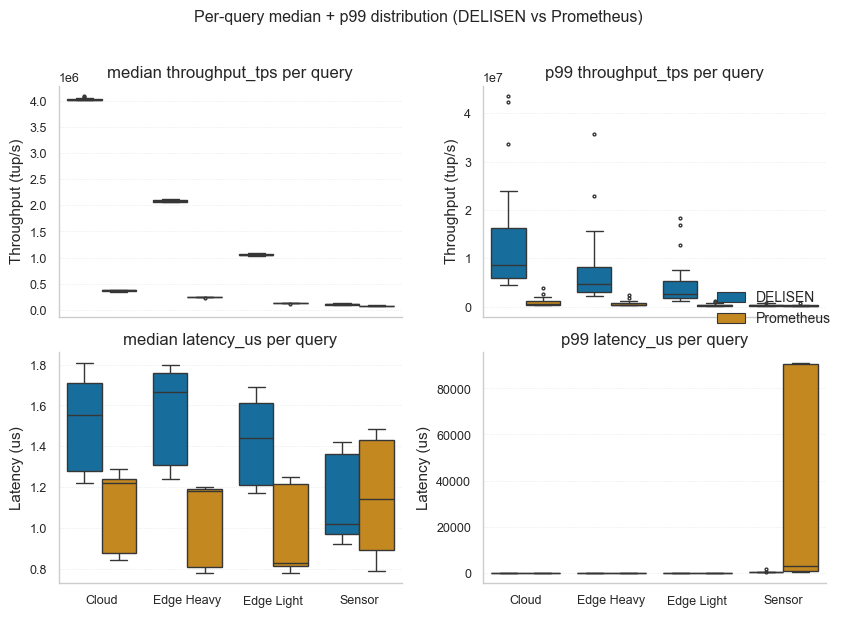

In [12]:
### Per-query distribution: each query contributes two points (its median and its p99) per metric.
### Box plot shows the spread across queries (median + IQR + whiskers + outlier dots).
### rows = metric, cols = aggregation, x = condition, hue = run.

per_query_long = pd.concat(
    [
        tp_per_query.assign(metric="throughput_tps", aggregation="median", value=tp_per_query["median"]),
        tp_per_query.assign(metric="throughput_tps", aggregation="p99",    value=tp_per_query["p99"]),
        lat_per_query_us.assign(metric="latency_us", aggregation="median", value=lat_per_query_us["median_us"]),
        lat_per_query_us.assign(metric="latency_us", aggregation="p99",    value=lat_per_query_us["p99_us"]),
    ],
    ignore_index=True,
)[["condition", "run", "query_id", "metric", "aggregation", "value"]]
per_query_long = map_display_columns(per_query_long)

with sns.plotting_context("paper", rc={
    "axes.labelsize": 11, "axes.titlesize": 12, "legend.fontsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
}):
    palette = sns.color_palette("colorblind", n_colors=len(RUN_NAMES))
    g = sns.catplot(
        data=per_query_long,
        x="condition_display",
        order=CONDITION_DISPLAY_ORDER,
        y="value",
        hue="run_display",
        hue_order=RUN_DISPLAY_ORDER,
        palette=palette,
        row="metric",
        row_order=["throughput_tps", "latency_us"],
        col="aggregation",
        col_order=["median", "p99"],
        kind="box",
        height=3.0,
        aspect=1.2,
        sharey=False,
        fliersize=2,
    )
    for (metric, aggregation), ax in g.axes_dict.items():
        ax.set_xlabel("")
        ax.set_ylabel("Throughput (tup/s)" if metric == "throughput_tps" else "Latency (us)")
        ax.set_title(f"{aggregation} {metric} per query")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)
    if g._legend is not None:
        g._legend.set_title(None)
    g.fig.suptitle("Per-query median + p99 distribution (DELISEN vs Prometheus)", y=1.02)
    plt.tight_layout()
    FIGURES["per_query_median_p99"] = g.fig
    plt.show()

## Save figures

Writes every figure created above as both `.png` (raster, 300 dpi) and `.pdf` (vector) into `<BENCHMARK_RUN>/figures/`. PDFs are the right format for paper inclusion; PNGs are useful for slides / quick previews.

In [13]:
SAVE_DIR = os.path.join(BENCHMARK_RUN, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

for name, fig in FIGURES.items():
    for ext, kwargs in [("png", {"dpi": 300}), ("pdf", {})]:
        path = os.path.join(SAVE_DIR, f"{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"saved: {os.path.abspath(path)}")

saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/figures/per_query_throughput.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/figures/per_query_throughput.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/figures/aggregate_throughput.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/figures/aggregate_throughput.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/multiple-statistic-queries-over-time-prometheus/plots/figures/plot3_aggregate_throughput.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/m